In [94]:
## DO NOT OPEN THE ./temp folder !!!! IT HAS A LOTTT OF PAIRS

### Setup

In [2]:
%load_ext autoreload
%autoreload 2

In [14]:
# Imports
import numpy as np
import sys
from pathlib import Path
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent, SaliencyMapMethod, CarliniL2Method

import art.attacks.evasion.projected_gradient_descent.projected_gradient_descent_pytorch as _pgd_pt
_pgd_pt.compute_success = lambda *a, **kw: 0.0

sys.path.append(str(Path.cwd().parents[1]))

from utils.functions import get_windowed_data, denormalize
from utils.notebook import get_model_classifier, clean_data_test, adv_test, FilenameLoader
from MBD_systems.windowed_eval import split_csv_by_sender_receiver

In [4]:
## Inputs
checkpoint_name, data_name, save_name = FilenameLoader.const_pos()

checkpoint_file= f"../../saved_models/{checkpoint_name}"
data_file = f"../../data/{data_name}"
save_path = f"../final_data/{save_name}"

collapsed = False # True for JSMA and CW
save_clean = False

In [5]:
## Load model and data
# Load original model and ART-wrapper classifier
# model, classifier = get_model_classifier(checkpoint_file, collapsed)

# Load data
(x_train, y_train), (x_test, y_test), fed_dataset, scaler = get_windowed_data(data_file, 
                                                                      normalize=True, 
                                                                      train_perc=80)


In [6]:
(x_train_og, y_train_og), (x_test_og, y_test_og), _, _ = get_windowed_data(data_file, 
                                                                      normalize=False, 
                                                                      train_perc=80)


### Checks

In [8]:
# Check that scaler works and matches og data
# Diff should be close to 0
maxes = []
for idx in range(len(x_test_og)):
    out1 = x_test_og[idx]
    out2 = denormalize(x_test[idx], scaler)

    out3 = out2 - out1.numpy()
    out4 = out3.flatten()
    maxes.append(max(out4))
max(maxes)

np.float64(0.0013367487808864098)

### With Attack Generation

a concept of a plan: 

- determine the (denormalized) change in meters
- the biggest and smallest change should be within 10 meters for it to be "constant" 

the function:
- input: a window (10 messages) of before and after adv testing
- output: true, false whether it's "constant" or not

#### Setup

In [7]:
from art.attacks.evasion import FastGradientMethod
from utils.notebook import get_model_classifier

def is_window_constant(x_test, x_test_adv, index, scaler, threshold=10):
    # Denormalized (original units) versions of the same values
    x_denorm = denormalize(x_test[index], scaler)
    x_adv_denorm = denormalize(x_test_adv[index], scaler)

    diff = x_denorm - x_adv_denorm
    points = diff[:, 1:3]  # (10, 2) -> (dx, dy) per message

    max_pairwise = max(
        np.linalg.norm(points[i] - points[j])
        for i in range(len(points)) for j in range(i + 1, len(points))
    )

    return max_pairwise < threshold, max_pairwise


In [8]:
model, classifier = get_model_classifier(checkpoint_file)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/reu/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Checkpoint path exists!


#### Run analysis

In [ ]:
## Create x_test_adv
eps = 0.0012
attack = FastGradientMethod(estimator=classifier, eps=eps, targeted=True)
# attack = ProjectedGradientDescent(estimator=classifier, eps=eps, targeted=True, max_iter=5)

x_test_adv = attack.generate(x=x_test.numpy(), y=1 - y_test.numpy())

In [15]:
## Find the indices that are labeled as attackers, use algorithm
threshold = 10
print("Current eps:", eps)
print("Current threshold:", threshold)
attack_indices = []
tr, fa = 0, 0 # true constants, and false constants
diffs = []
for i in range(len(y_test)):
    if (y_test[i] == 1).all():
        print(i)
        attack_indices.append(i)
        is_const, max_diff = is_window_constant(x_test, x_test_adv, i, scaler, threshold=threshold)
        if(is_const): tr += 1
        else: fa += 1
        diffs.append(max_diff)

## Print results
lst, freqs = np.unique(diffs, return_counts=True)
print("unique diffs", lst)
print("unique freqs", freqs)
print("max", round(max(diffs), 4), "m")
print("tr:", tr, "| fa:", fa)
print("% of non-const windows:", str(round(fa/(fa+tr)*100, 4)) + "%")


Current eps: 0.003
Current threshold: 10
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
474
475
476
477
478
479
480
481
482
483
484
485
486
487
488
489
490
491
492
493
494
495
496
497
498
499
500
501
502
503
504
505
506
507
508
509
510
511
1126
1127
1128
1129
1130
1131
1132
1133
1134
1135
1136
1137
1138
1139
1140
1141
1142
1143
1144
1145
1146
1147
1148
1149
1150
1151
1152
1153
1154
1155
1156
1157
1158
1159
1160
1161
1162
1163
1164
1165
1166
1167
1168
1169
1170
1171
1172
1173
1174
1175
1176
1177
1178
1179
1180
1181
1182
1183
1184
1185
1186
1187
1188
1189
1190
1191
1192
1193
1194
1195
1196
1197
1198
1199
1200
1201
1202
1203
1204
1205
1206
1207
1208
1209
1210
1211
1212
1213
1214
1215
1216
1217
1218
1219
1220
1221
1222
1223
1224
1225
1226
1227
1228
1229
1230
1231
1232
1233
1234
1235
1236
1237
1238
1239
1240
1241
1242
1243
1244
1245
1246
1247
1248
1249
1250
1251
1252
1253
1254
1255
1256


In [19]:
## Run clean data test that the attack affects model performance
out = clean_data_test(model = model, classifier = classifier, # model information
                x_test=x_test_adv, y_test=y_test, # data information
                checkpoint_file=checkpoint_file, data_file=data_file, # to save in json
                save_path=None, filename=None, # saving information
                save_results=False,
                collapsed=False
                ) 

# Check if output fails
print('f1', out['wrapper']['f1'])
print('fpr', out['wrapper']['falsePositiveRate'])
print('fnr', out['wrapper']['falseNegativeRate'])

save=False, Metrics not saved
Metrics {'noWrapper': {'accuracy': 0.8100285315851059, 'recall': 0.8953898030752631, 'precision': 0.6260569583365555, 'f1': 0.7368841695370179, 'falseNegativeRate': 0.10461019692473698, 'falsePositiveRate': 0.22605126334032655, 'TP': 331921, 'TN': 678784, 'FP': 198256, 'FN': 38779}, 'wrapper': {'accuracy': 0.8100285315851059, 'precision': 0.6260569583365555, 'recall': 0.8953898030752631, 'f1': 0.7368841695370179, 'falseNegativeRate': 0.10461019692473698, 'falsePositiveRate': 0.22605126334032655, 'TP': 331921, 'TN': 678784, 'FP': 198256, 'FN': 38779}, 'files': {'checkpointFile': '../../saved_models/ConstantPos-final.ckpt', 'dataFile': '../../data/ConstPos_0709.csv'}}
f1 0.7368841695370179
fpr 0.22605126334032655
fnr 0.10461019692473698


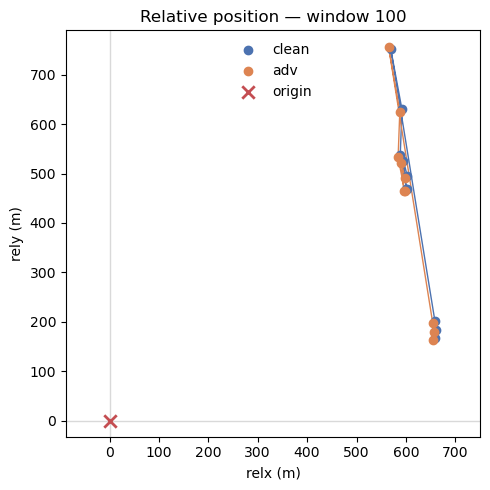

In [17]:
import matplotlib.pyplot as plt

def plot_relative_positions(x_denorm, x_adv_denorm, index=None, ax=None, title=None):
    """Scatter relx (col 1) vs rely (col 2) for clean vs. adversarial windows of 10 messages."""
    own_ax = ax is None
    if own_ax:
        fig, ax = plt.subplots(figsize=(5, 5))

    series = [
        ("clean", x_denorm, "#4C72B0"),
        ("adv", x_adv_denorm, "#DD8452"),
    ]

    for label, data, color in series:
        relx = data[:, 1]
        rely = data[:, 2]
        ax.plot(relx, rely, "-", color=color, linewidth=1, zorder=1)
        ax.scatter(relx, rely, color=color, s=36, zorder=2, label=label)

    # origin, marked distinctly
    ax.scatter(0, 0, color="#C44E52", marker="x", s=80, linewidth=2, zorder=3, label="origin")

    ax.axhline(0, color="0.85", linewidth=1, zorder=0)
    ax.axvline(0, color="0.85", linewidth=1, zorder=0)

    ax.set_xlabel("relx (m)")
    ax.set_ylabel("rely (m)")
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(title or (f"Relative position — window {index}" if index is not None else "Relative position"))
    ax.legend(frameon=False)

    if own_ax:
        plt.tight_layout()
        plt.show()

# usage
index = 100
x_denorm = denormalize(x_test[index], scaler)
x_adv_denorm = denormalize(x_test_adv[index], scaler)
plot_relative_positions(x_denorm, x_adv_denorm, index=index)